In [ ]:
pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [347]:
df = pd.read_csv("/content/Energy_consumption_dataset.csv")
print(df)

      Month  Hour DayOfWeek Holiday  Temperature   Humidity  SquareFootage  \
0         1     0  Saturday      No    25.139433  43.431581    1565.693999   
1         1     1  Saturday      No    27.731651  54.225919    1411.064918   
2         1     2  Saturday      No    28.704277  58.907658    1755.715009   
3         1     3  Saturday      No    20.080469  50.371637    1452.316318   
4         1     4  Saturday      No    23.097359  51.401421    1094.130359   
...     ...   ...       ...     ...          ...        ...            ...   
4995     12     6    Sunday     Yes    26.338718  52.580000    1563.567259   
4996     12    17    Monday      No    20.007565  42.765607    1999.982252   
4997     12    13  Thursday     Yes    26.226253  30.015975    1999.982252   
4998     12     8  Saturday     Yes    24.673206  50.223939    1240.811298   
4999     12     1  Saturday     Yes    25.802872  41.798829    1793.658686   

      Occupancy HVACUsage LightingUsage  RenewableEnergy  Energ

In [376]:
for col_name in df.columns:
  print(f"{col_name} : {df[col_name].dtype}")

Month : int64
Hour : int64
DayOfWeek : int64
Holiday : int64
Temperature : float64
Humidity : float64
SquareFootage : float64
Occupancy : int64
HVACUsage : int64
LightingUsage : int64
RenewableEnergy : float64
EnergyConsumption : float64


In [384]:
le = LabelEncoder()
scaler = StandardScaler()

for col in df:
  if df[col].dtype == "object":
    df[col] = le.fit_transform(df[col].astype(str))

print(df)

y = df['EnergyConsumption']

x = df.drop(['EnergyConsumption'], axis=1)

for col in x:
  if x[col].isnull().sum() > 0 and x[col].dtype != "object":
    x[col].fillna(x[col].mean(), inplace=True)
    scaler.fit(x[[col]])
    x[col] = scaler.transform(x[[col]])
  # else:
  #   imputer = SimpleImputer(strategy="most_frequent")
  #   df[col] = imputer.fit_transform(df[[col]]).ravel()




      Month  Hour  DayOfWeek  Holiday  Temperature   Humidity  SquareFootage  \
0         1     0          2        0    25.139433  43.431581    1565.693999   
1         1     1          2        0    27.731651  54.225919    1411.064918   
2         1     2          2        0    28.704277  58.907658    1755.715009   
3         1     3          2        0    20.080469  50.371637    1452.316318   
4         1     4          2        0    23.097359  51.401421    1094.130359   
...     ...   ...        ...      ...          ...        ...            ...   
4995     12     6          3        1    26.338718  52.580000    1563.567259   
4996     12    17          1        0    20.007565  42.765607    1999.982252   
4997     12    13          4        1    26.226253  30.015975    1999.982252   
4998     12     8          2        1    24.673206  50.223939    1240.811298   
4999     12     1          2        1    25.802872  41.798829    1793.658686   

      Occupancy  HVACUsage  LightingUsa

In [361]:
y.dtype

dtype('float64')

In [368]:
y

array([[-0.15497777],
       [ 0.71576066],
       [ 0.15989869],
       ...,
       [ 0.97389616],
       [-1.40953434],
       [-2.54929405]])

In [378]:
y.value_counts()

,count
EnergyConsumption,
99.201120,37
53.263278,28
83.785540,1
74.804130,1
78.239477,1
...,...
66.357650,1
88.193214,1
86.273501,1


In [335]:
# SMOTE is typically used for classification tasks with imbalanced classes.
# Since we are performing a regression task, SMOTE is not applicable here.
# The related lines for SMOTE have been commented out or removed.

# smote = SMOTE(random_state=42)
# x_resampled, y_resampled = smote.fit_resample(x, y)

# print("Original y_train value counts:")
# print(y.value_counts())
# print("\nResampled y_train value counts (after SMOTE):")
# print(y_resampled.value_counts())

In [385]:
# Use the 'x' and 'y' variables prepared for EnergyConsumption regression
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [379]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 11)
(1000, 11)
(4000,)
(1000,)


In [392]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error)

# from xgboost import XGBClassifier # Not needed for regression

# xgb_model = XGBRegressor(
#    n_estimators=300,
#     learning_rate=0.1,
#     max_depth=5,

#     random_state=42,
#     n_jobs=-1,

#     colsample_bytree=0.7,
#     subsample=0.8,

#     objective='reg:squarederror',
#     tree_method='auto' # Corrected to 'auto' to resolve XGBoostError)

xgb_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=30,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

# These metrics are for classification and were commented out anyway.
# accuracy_scores = accuracy_score(y_test, y_pred)
# precision_scores = precision_score(y_test, y_pred)
# recall_scores = recall_score(y_test, y_pred)
# f1_scores = f1_score(y_test, y_pred) # caluculate metrics considering class imbalance

# print(f"""
# Accuracy Score : {accuracy_scores}
# Precision Score : {precision_scores}
# Recall Score : {recall_scores}
# F1 Score : {f1_scores} """)

r2_score_val = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2_score_val}")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")

R2 Score: 0.2201078315330306
Mean Absolute Error: 6.39307695581747
Mean Squared Error: 65.09355802236978


In [382]:
y_train.value_counts()

,count
EnergyConsumption,
99.201120,28
53.263278,21
62.444699,1
83.862247,1
79.668310,1
...,...
82.332424,1
81.130396,1
66.654606,1


In [373]:
y_test.value_counts()

,count
EnergyConsumption,
99.201120,9
53.263278,7
60.627871,1
71.618399,1
62.001894,1
...,...
74.843850,1
80.972008,1
90.325878,1


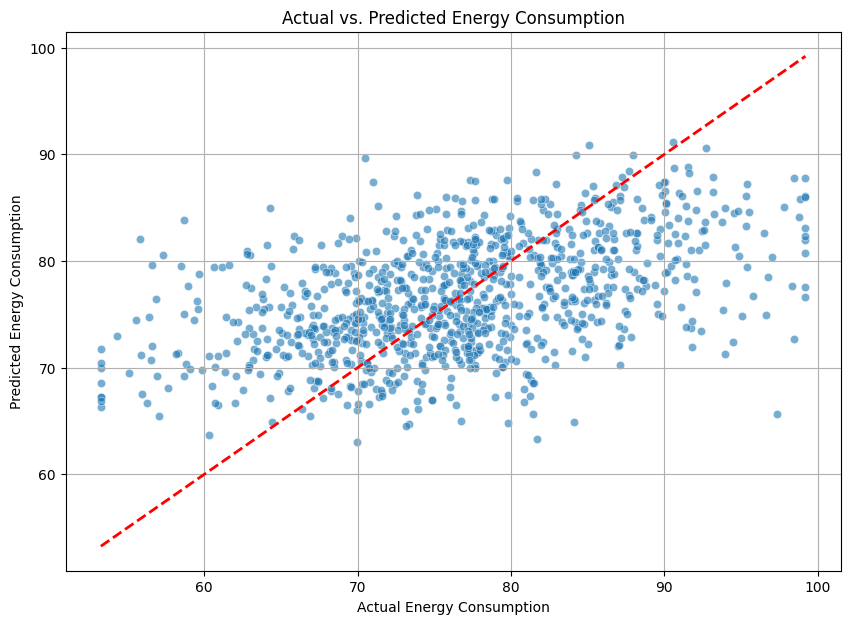

In [393]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6) # Removed .flatten() as y_test is a Series
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted Energy Consumption') # Updated title
plt.xlabel('Actual Energy Consumption') # Updated label
plt.ylabel('Predicted Energy Consumption') # Updated label
plt.grid(True)
plt.show()

In [394]:
import joblib
if joblib.dump(xgb_model, 'energy consumption.pkl'):
  print("model saved")

model saved
